In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import geopandas as gpd
from shapely.geometry import Point

In [ ]:
conn = sqlite3.connect("base_tratada.db")

query = """
SELECT *
FROM base_tratada;
"""

df = pd.read_sql(query, conn)

# Visualizar os dados
df.head()

#testando se o banco conectou



,preco,hospedes,quartos,camas,nota_avaliacao,noites_minimas,quantidade_avaliacoes,tipo_de_propriedade,latitude,longitude,...,banheiros,tipo_quarto_Entire home/apt,tipo_quarto_Hotel room,tipo_quarto_Private room,tipo_quarto_Shared room,tipo_de_propriedade_grupo,bairro_encode,ano_mes,ipca_mensal,ipca_acumulado_ano
0,580.0,4,2.0,3.0,4.93,2,86,entire condo,-22.982818,-43.222457,...,1.5,1,0,0,0,1,76,2025-09-01 00:00:00,0.0048,0.0426
1,1900.0,2,1.0,1.0,NaN,5,0,entire rental unit,-22.984090,-43.191770,...,2.0,1,0,0,0,1,34,2025-09-01 00:00:00,0.0048,0.0426
2,700.0,4,1.0,1.0,NaN,1,0,entire rental unit,-22.814911,-43.379011,...,1.0,1,0,0,0,1,96,2025-09-01 00:00:00,0.0048,0.0426
3,NaN,2,NaN,NaN,5.00,2,3,private room in rental unit,-22.981910,-43.225990,...,1.0,0,0,1,0,4,76,2025-09-01 00:00:00,0.0048,0.0426
4,500.0,4,1.0,1.0,4.91,2,11,entire rental unit,-23.010000,-43.344820,...,1.0,1,0,0,0,1,8,2025-09-01 00:00:00,0.0048,0.0426


In [4]:

df.shape
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 43068 entries, 0 to 43067
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   preco                        38670 non-null  float64
 1   hospedes                     43068 non-null  int64  
 2   quartos                      42096 non-null  float64
 3   camas                        38660 non-null  float64
 4   nota_avaliacao               33882 non-null  float64
 5   noites_minimas               43068 non-null  int64  
 6   quantidade_avaliacoes        43068 non-null  int64  
 7   tipo_de_propriedade          43068 non-null  str    
 8   latitude                     43068 non-null  float64
 9   longitude                    43068 non-null  float64
 10  bairro                       43068 non-null  str    
 11  ano                          43068 non-null  int64  
 12  mes                          43068 non-null  int64  
 13  banheiros                  

In [6]:
df["preco"].describe()

#antes do tratamento de outliers

count     38670.000000
mean        717.535325
std        4388.082802
min          30.000000
25%         202.000000
50%         317.000000
75%         565.000000
max      500000.000000
Name: preco, dtype: float64

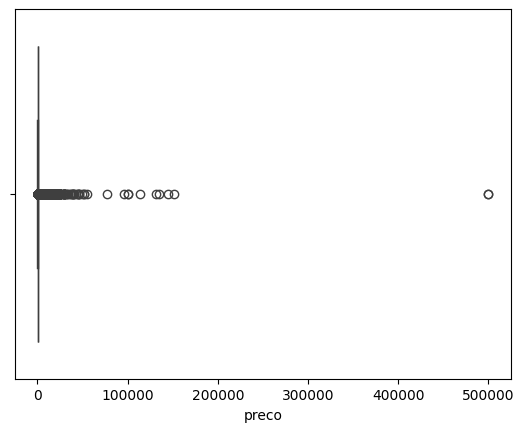

In [ ]:
sns.boxplot(x=df["preco"])
plt.show()

plt.show()

#grafico para avaliar os outliers no dataframe sem tratamento dos outliers


In [8]:
#outliers
df["preco"].sort_values(ascending=False).head(20)
#verificando valores

7624     500000.0
15026    500000.0
16440    151710.0
21203    144800.0
13282    134358.0
42536    131400.0
24598    114118.0
14389    100000.0
13880    100000.0
27939     96547.0
3146      76956.0
1854      55394.0
24256     51545.0
18525     51429.0
24053     50000.0
10694     45900.0
12548     45818.0
34736     45000.0
24697     45000.0
4401      42924.0
Name: preco, dtype: float64

In [9]:
df_tratado = df[df["preco"] <= 13000].copy()

#Limita o preco das diaria ate 13k

In [10]:
df.shape[0], df_tratado.shape[0]

#mostra os dois dataframes

(43068, 38506)

In [11]:

print(f"Antes: {df.shape[0]} linhas")
print(f"Depois: {df_tratado.shape[0]} linhas")
print(f"Removidos: {df.shape[0] - df_tratado.shape[0]} linhas")


Antes: 43068 linhas
Depois: 38506 linhas
Removidos: 4562 linhas


In [12]:
df_tratado["preco"].describe()

count    38506.000000
mean       579.125825
std        967.825157
min         30.000000
25%        201.000000
50%        315.000000
75%        558.000000
max      13000.000000
Name: preco, dtype: float64

In [13]:
df["preco"].sort_values(ascending=True).head(20)

#mostra valores em forma crescente

5386     30.0
6624     39.0
9388     40.0
42145    41.0
10249    42.0
24389    43.0
11471    43.0
42673    44.0
21734    44.0
14333    46.0
27704    46.0
4048     46.0
8908     46.0
6474     47.0
22890    48.0
9135     48.0
9908     48.0
37698    48.0
7530     48.0
8598     48.0
Name: preco, dtype: float64

In [14]:

df_tratado_price_min = df_tratado[
    (df_tratado["preco"] >= 65) &
    (df_tratado["quartos"] <= 15) &
    (df_tratado["banheiros"] <= 12)
].copy()

#atribui ao novo dataframe valores de limete pós remocao de outliers



In [15]:
print(f"Antes: {df_tratado.shape[0]} linhas")
print(f"Depois: {df_tratado_price_min.shape[0]} linhas")
print(f"Removidos: {df_tratado.shape[0] - df_tratado_price_min.shape[0]} linhas")

Antes: 38506 linhas
Depois: 37937 linhas
Removidos: 569 linhas


In [16]:
df_tratado_price_min["preco"].describe()

count    37937.000000
mean       583.569971
std        971.368256
min         65.000000
25%        204.000000
50%        319.000000
75%        563.000000
max      13000.000000
Name: preco, dtype: float64

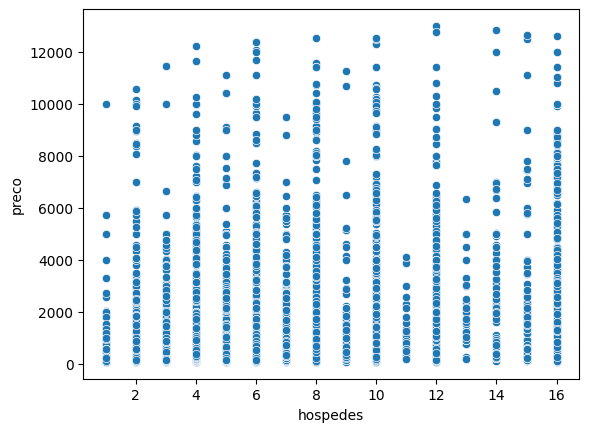

In [17]:
sns.scatterplot(x="hospedes", y="preco", data=df_tratado_price_min)
plt.show()

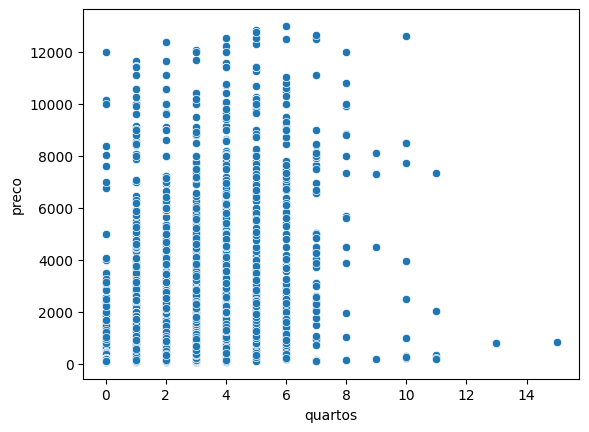

In [18]:
sns.scatterplot(x="quartos", y="preco", data=df_tratado_price_min)
plt.show()

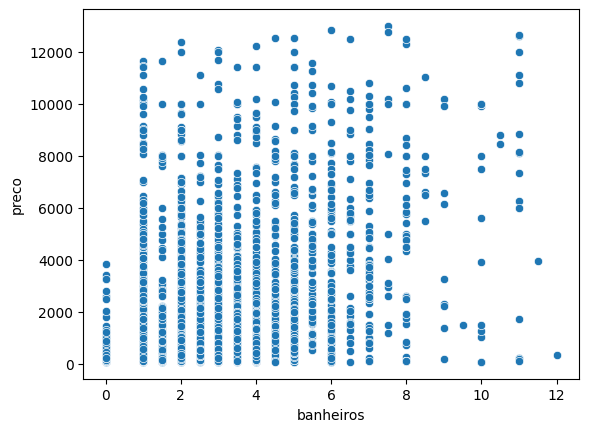

In [19]:
sns.scatterplot(x="banheiros", y="preco", data=df_tratado_price_min)
plt.show()

In [20]:

df_tratado_price_min[
    [
        "preco",
        "hospedes",
        "quartos",
        "camas",
        "nota_avaliacao",
        "noites_minimas",
        "quantidade_avaliacoes",
        "latitude",
        "longitude",
        "banheiros",
        "tipo_quarto_Entire home/apt",
        "tipo_quarto_Hotel room",
        "tipo_quarto_Private room",
        "tipo_quarto_Shared room"
    ]
].describe()


,preco,hospedes,quartos,camas,nota_avaliacao,noites_minimas,quantidade_avaliacoes,latitude,longitude,banheiros,tipo_quarto_Entire home/apt,tipo_quarto_Hotel room,tipo_quarto_Private room,tipo_quarto_Shared room
count,37937.000000,37937.000000,37937.000000,37926.000000,30161.000000,37937.000000,37937.000000,37937.000000,37937.000000,37937.000000,37937.000000,37937.000000,37937.000000,37937.000000
mean,583.569971,3.983631,1.498353,2.366240,4.814117,3.430450,27.821098,-22.966040,-43.248507,1.479756,0.818779,0.000395,0.173182,0.007644
std,971.368256,2.284737,0.942994,2.070306,0.351818,13.370886,50.298927,0.035845,0.101305,0.922917,0.385207,0.019881,0.378409,0.087098
min,65.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,-23.072920,-43.713593,0.000000,0.000000,0.000000,0.000000,0.000000
25%,204.000000,2.000000,1.000000,1.000000,4.770000,1.000000,1.000000,-22.984323,-43.301941,1.000000,1.000000,0.000000,0.000000,0.000000
50%,319.000000,4.000000,1.000000,2.000000,4.920000,2.000000,8.000000,-22.971860,-43.193427,1.000000,1.000000,0.000000,0.000000,0.000000
75%,563.000000,5.000000,2.000000,3.000000,5.000000,3.000000,32.000000,-22.952940,-43.184380,2.000000,1.000000,0.000000,0.000000,0.000000
max,13000.000000,16.000000,15.000000,50.000000,5.000000,730.000000,760.000000,-22.750510,-43.104400,12.000000,1.000000,1.000000,1.000000,1.000000


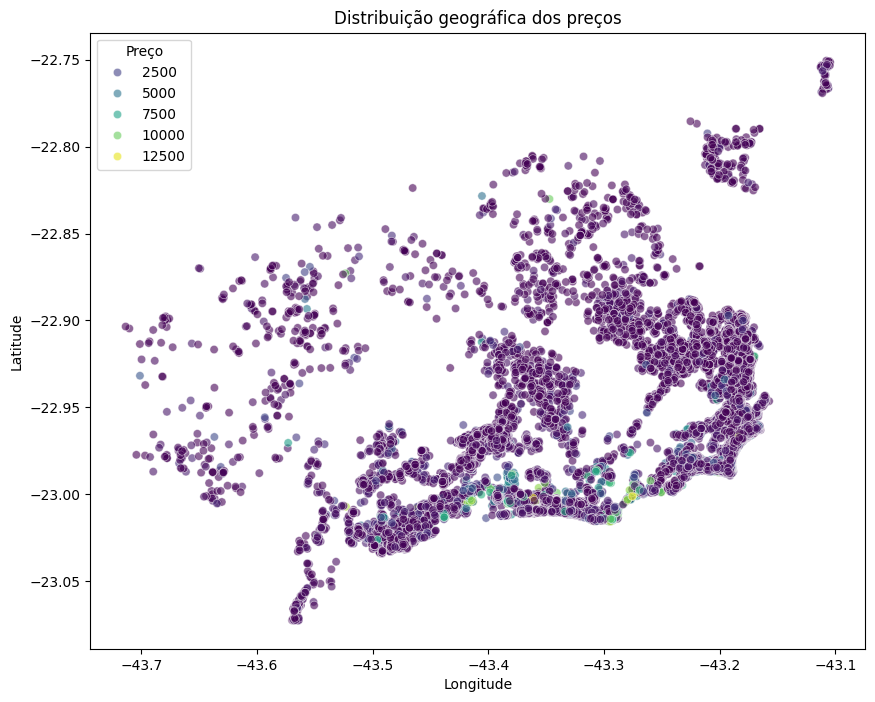

In [21]:

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_tratado_price_min,
    x="longitude",
    y="latitude",
    hue="preco",
    palette="viridis",
    alpha=0.6
)

plt.title("Distribuição geográfica dos preços")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Preço", loc="best")
plt.show()


In [22]:

df_tratado_price_min["lat_bin"] = df_tratado_price_min["latitude"].round(2)
df_tratado_price_min["lon_bin"] = df_tratado_price_min["longitude"].round(2)


In [23]:

media_localizacao = (
    df_tratado_price_min
    .groupby(["lat_bin", "lon_bin"])["preco"]
    .mean()
    .reset_index()
)


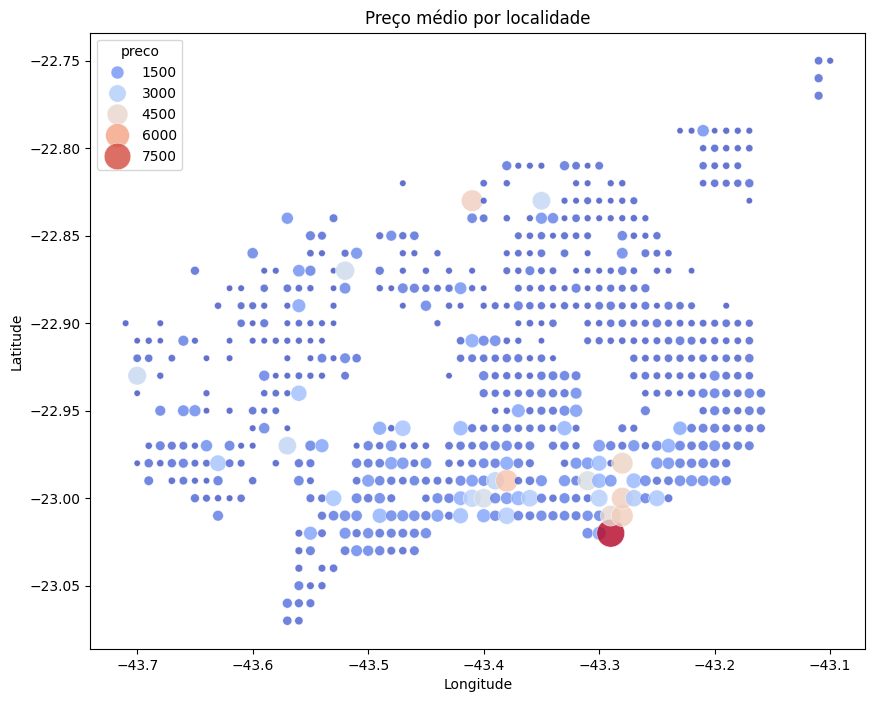

In [24]:

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=media_localizacao,
    x="lon_bin",
    y="lat_bin",
    size="preco",
    hue="preco",
    palette="coolwarm",
    sizes=(20, 400),
    alpha=0.8
)

plt.title("Preço médio por localidade")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [25]:

mapa = folium.Map(
    location=[
        df_tratado_price_min["latitude"].mean(),
        df_tratado_price_min["longitude"].mean()
    ],
    zoom_start=11
)


In [ ]:
df_tratado_price_min["lat_bin"] = df_tratado_price_min["latitude"].round(2)
df_tratado_price_min["lon_bin"] = df_tratado_price_min["longitude"].round(2)

In [ ]:
media_regiao = (
    df_tratado_price_min
    .groupby(["lat_bin", "lon_bin"])["preco"]
    .mean()
    .reset_index()
)

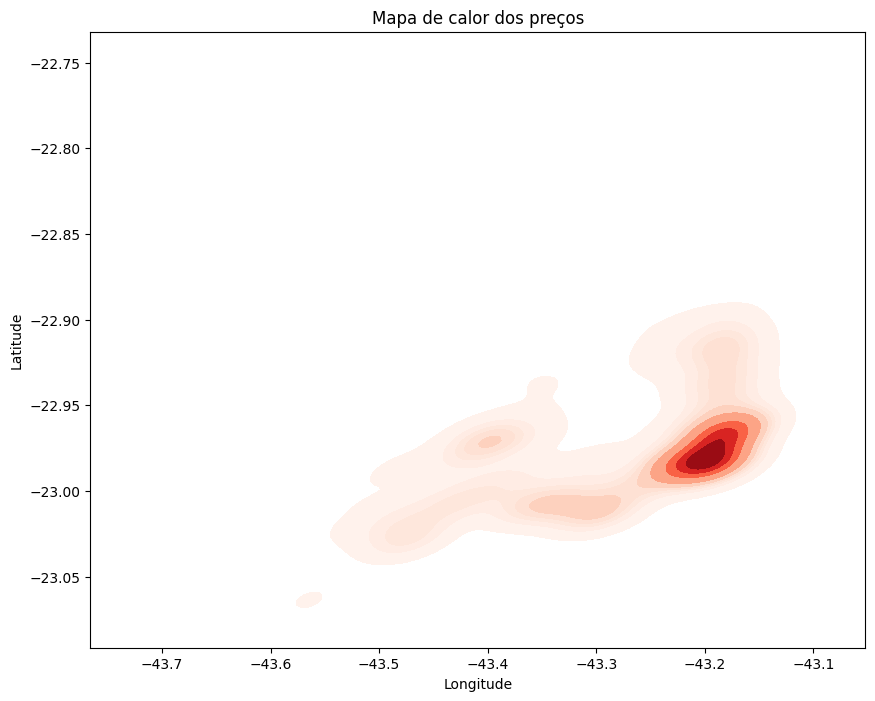

In [ ]:
plt.figure(figsize=(10, 8))
sns.kdeplot(
    x=df_tratado_price_min["longitude"],
    y=df_tratado_price_min["latitude"],
    weights=df_tratado_price_min["preco"],
    cmap="Reds",
    fill=True,
    thresh=0.05
)

plt.title("Mapa de calor dos preços")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [ ]:
geometry = [
    Point(xy)
    for xy in zip(df_tratado_price_min["longitude"], df_tratado_price_min["latitude"])
]

In [ ]:
gdf = gpd.GeoDataFrame(
    df_tratado_price_min,
    geometry=geometry,
    crs="EPSG:4326"  # sistema padrão de latitude/longitude
)

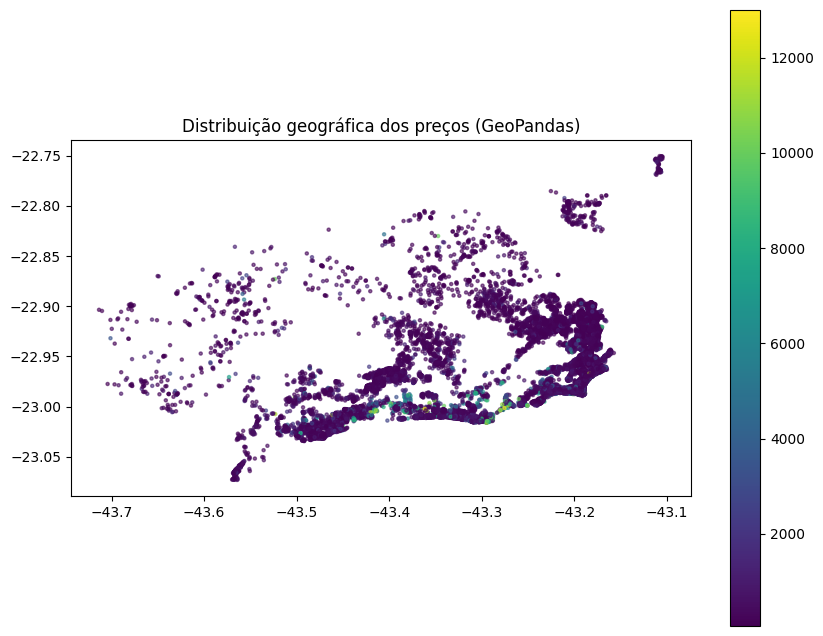

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

gdf.plot(
    ax=ax,
    column="preco",
    cmap="viridis",
    legend=True,
    markersize=5,
    alpha=0.6
)

plt.title("Distribuição geográfica dos preços (GeoPandas)")
plt.show()


In [ ]:
tipos_imovel = {
    "Casa/apt Inteiro": "tipo_quarto_Entire home/apt",
    "Quarto de Hotel": "tipo_quarto_Hotel room",
    "Quarto Privado": "tipo_quarto_Private room",
    "Quarto Compartilhado": "tipo_quarto_Shared room",
    "Outros": "tipo_de_propriedade_grupo"
}


In [ ]:
media_precos = []

for nome, coluna in tipos_imovel.items():
    preco_medio = df_tratado_price_min.loc[
        df_tratado_price_min[coluna] == 1, "preco"
    ].mean()
    
    media_precos.append({
        "Tipo de imóvel": nome,
        "Preço médio": preco_medio
    })

df_media = pd.DataFrame(media_precos)
df_media


,Tipo de imóvel,Preço médio
0,Casa/apt Inteiro,642.679544
1,Quarto de Hotel,619.800000
2,Quarto Privado,322.841705
3,Quarto Compartilhado,157.293103
4,Outros,641.653193


C:\Users\UL236KK\AppData\Local\Temp\ipykernel_29148\887207099.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


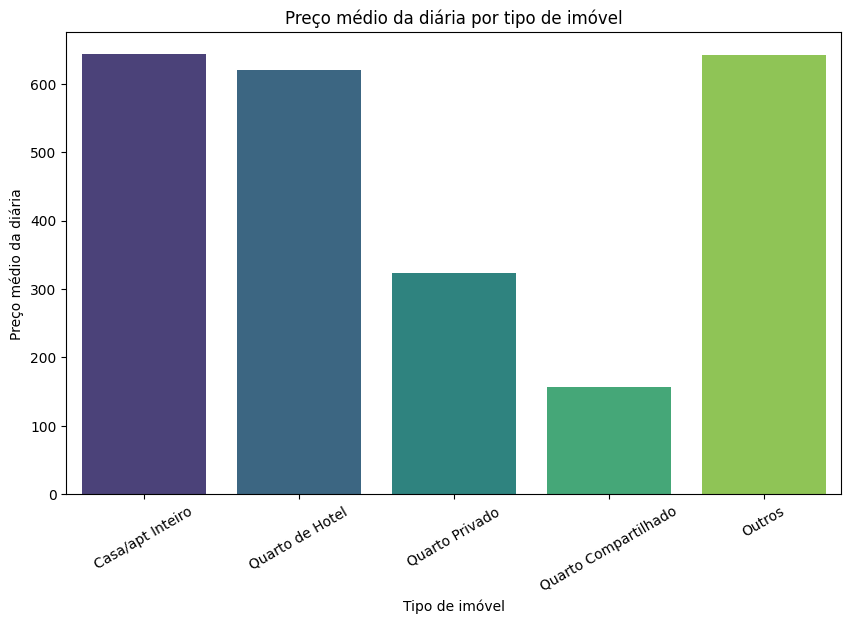

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_media,
    x="Tipo de imóvel",
    y="Preço médio",
    palette="viridis"
)

plt.title("Preço médio da diária por tipo de imóvel")
plt.xlabel("Tipo de imóvel")
plt.ylabel("Preço médio da diária")
plt.xticks(rotation=30)
plt.show()


In [35]:
df_tratado_price_min[df_tratado_price_min["bairro"] == "Copacabana"]["preco"].mean()

np.float64(501.7656826568266)

In [36]:

top_bairros = (
    df_tratado_price_min
    .groupby("bairro")
    .size()
    .reset_index(name="total_anuncios")
    .sort_values("total_anuncios", ascending=False)
    .head(10)
)


In [37]:

df_media_acomodacao = (
    df_tratado_price_min
    .groupby("bairro")["preco"]
    .mean()
    .reset_index()
)

# manter apenas bairros mais procurados
df_media_acomodacao = df_media_acomodacao.merge(
    top_bairros[["bairro"]],
    on="bairro",
    how="inner"
)


In [38]:

df_media_acomodacao = df_media_acomodacao.sort_values("preco", ascending=False)


C:\Users\UL236KK\AppData\Local\Temp\ipykernel_29148\2460075909.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


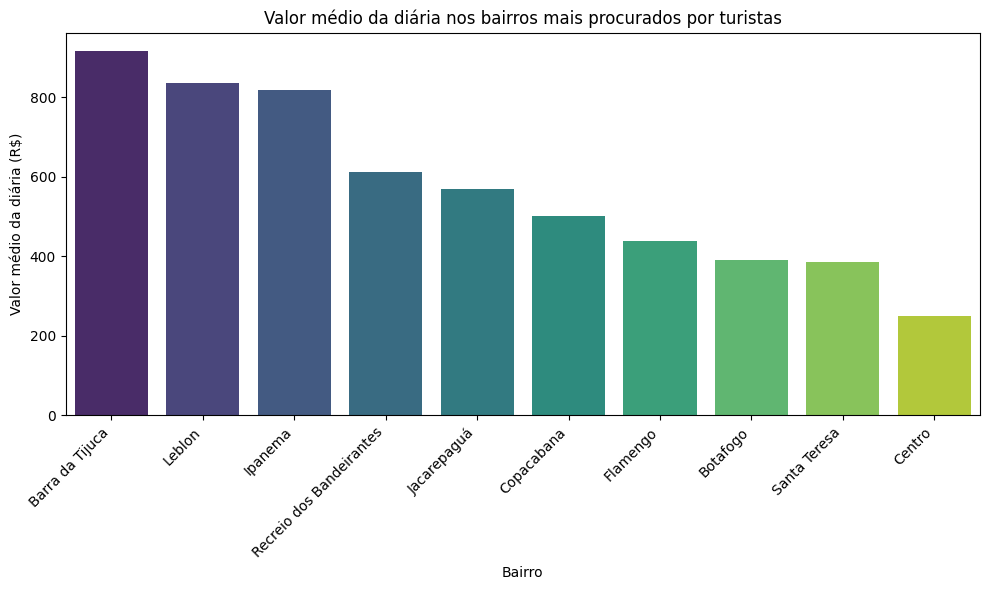

In [39]:

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_media_acomodacao,
    x="bairro",
    y="preco",
    palette="viridis"
)

plt.title("Valor médio da diária nos bairros mais procurados por turistas")
plt.xlabel("Bairro")
plt.ylabel("Valor médio da diária (R$)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [44]:

variaveis = [
    "preco",
    "quartos",
    "banheiros",
    "latitude",
    "longitude",
    "camas",
    "nota_avaliacao",
    "quantidade_avaliacoes",
    "tipo_quarto_Entire home/apt",
    "tipo_quarto_Hotel room",
    "tipo_quarto_Private room",
    "tipo_quarto_Shared room"
]

df_corr = df_tratado_price_min[variaveis]


In [45]:
corr_matrix = df_corr.corr()

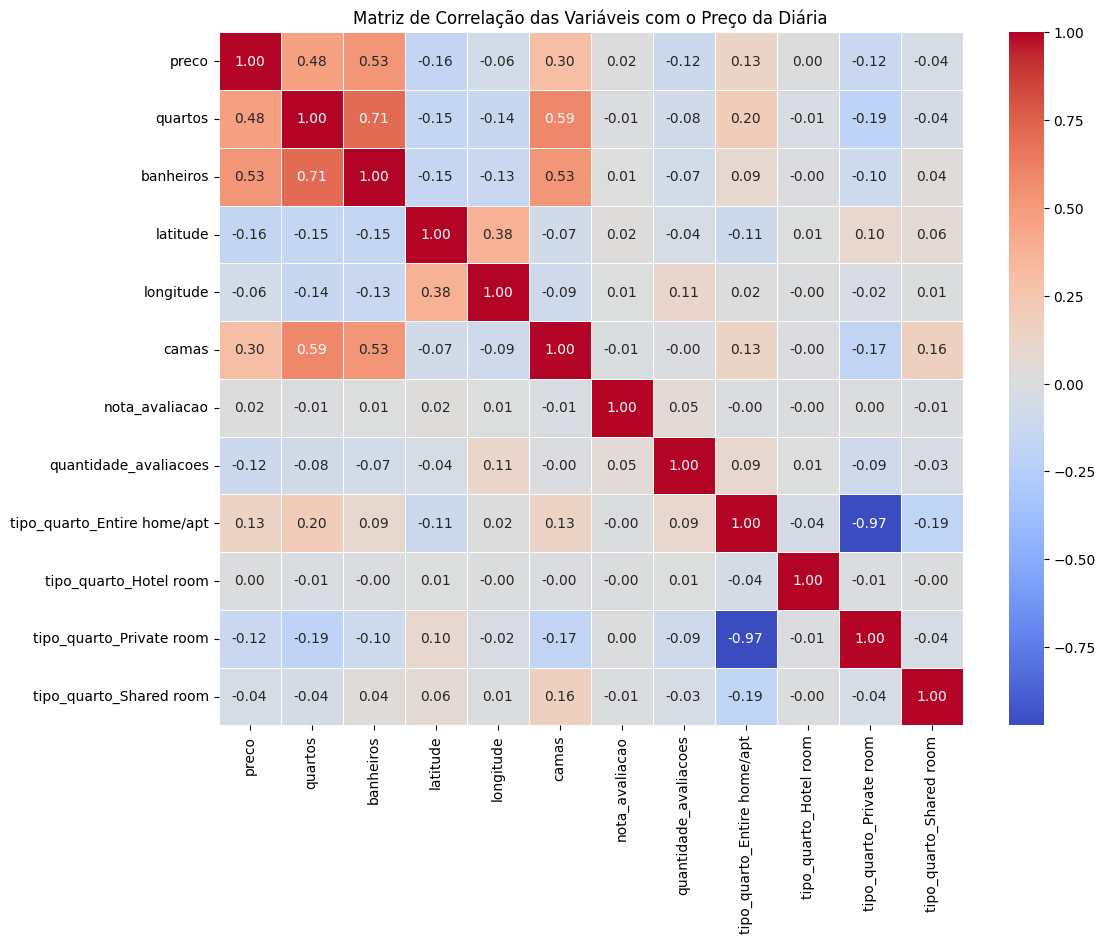

In [46]:

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matriz de Correlação das Variáveis com o Preço da Diária")
plt.show()


In [ ]:

corr_preco = corr_matrix["preco"].sort_values(ascending=False)
corr_preco


preco                          1.000000
banheiros                      0.527382
quartos                        0.475244
camas                          0.301778
tipo_quarto_Entire home/apt    0.129347
nota_avaliacao                 0.016159
tipo_quarto_Hotel room         0.000742
tipo_quarto_Shared room       -0.038517
longitude                     -0.064275
quantidade_avaliacoes         -0.115186
tipo_quarto_Private room      -0.122845
latitude                      -0.161848
Name: preco, dtype: float64

In [ ]:

df_tratado_price_min["bairro"].value_counts().head()


bairro
Copacabana                  11924
Ipanema                      3299
Barra da Tijuca              3255
Centro                       2012
Recreio dos Bandeirantes     1980
Name: count, dtype: int64

In [ ]:

df_demanda_bairro = (
    df_tratado_price_min
    .groupby("bairro")
    .size()
    .reset_index(name="total_imoveis")
    .sort_values("total_imoveis", ascending=False)
)


In [ ]:
top_bairros_turisticos = df_demanda_bairro.head(10)

In [ ]:

df_preco_bairro = (
    df_tratado_price_min
    .groupby("bairro")["preco"]
    .median()
    .reset_index()
)


In [ ]:

df_preco_bairro = df_preco_bairro.merge(
    top_bairros_turisticos[["bairro"]],
    on="bairro",
    how="inner"
)


In [ ]:
df_preco_bairro = df_preco_bairro.sort_values("preco", ascending=False)

C:\Users\UL236KK\AppData\Local\Temp\ipykernel_19716\3495948675.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


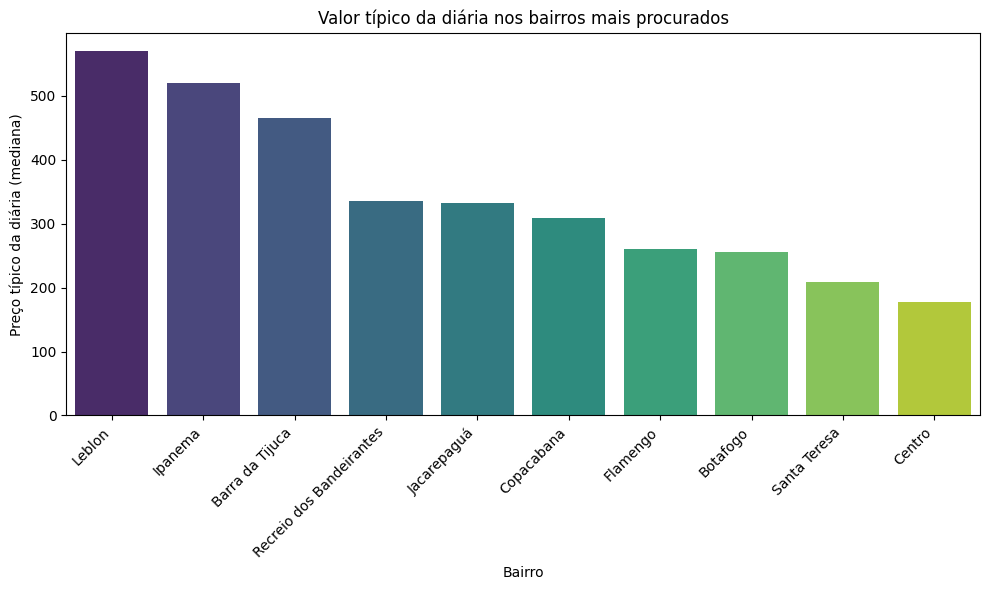

In [ ]:

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_preco_bairro,
    x="bairro",
    y="preco",
    palette="viridis"
)

plt.title("Valor típico da diária nos bairros mais procurados")
plt.xlabel("Bairro")
plt.ylabel("Preço típico da diária (mediana)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
df_tratado_price_min["banheiros"].value_counts().sort_index()

banheiros
0.0       303
1.0     24284
1.5      1908
2.0      7452
2.5      1005
3.0      1536
3.5       381
4.0       377
4.5       132
5.0       165
5.5        77
6.0       105
6.5        45
7.0        65
7.5        12
8.0        42
8.5         7
9.0         9
9.5         1
10.0       12
10.5        2
11.0       15
11.5        1
12.0        1
Name: count, dtype: int64

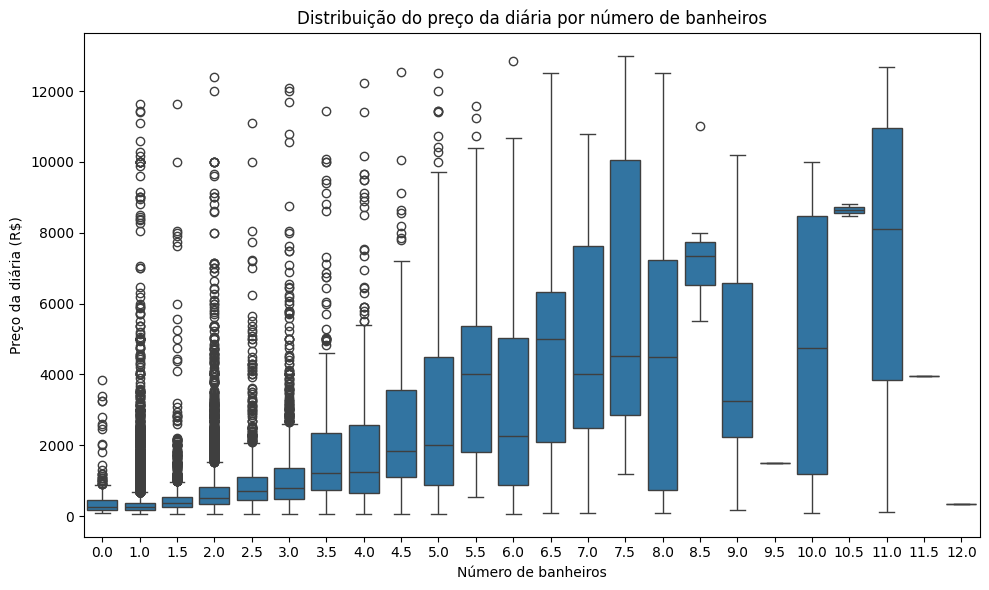

In [ ]:

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_tratado_price_min,
    x="banheiros",
    y="preco"
)

plt.title("Distribuição do preço da diária por número de banheiros")
plt.xlabel("Número de banheiros")
plt.ylabel("Preço da diária (R$)")
plt.tight_layout()
plt.show()


In [52]:

tipos_acomodacao = {
    "Casa/Apt Inteiro": "tipo_quarto_Entire home/apt",
    "Quarto de Hotel": "tipo_quarto_Hotel room",
    "Quarto Privado": "tipo_quarto_Private room",
    "Quarto Compartilhado": "tipo_quarto_Shared room"
}

In [53]:

dados_precos = []

for tipo, coluna in tipos_acomodacao.items():
    preco_medio = df_tratado_price_min.loc[
        df_tratado_price_min[coluna] == 1,
        "preco"
    ].mean()
    
    dados_precos.append({
        "Tipo de acomodação": tipo,
        "Preço no mês": preco_medio
    })

df_precos_tipo = pd.DataFrame(dados_precos)


In [54]:
ipca_atual = 5.5


df_precos_tipo["Preço corrigido hoje"] = (
    df_precos_tipo["Preço no mês"] *
    (1 + ipca_atual / 100)
)


In [55]:

df_plot = df_precos_tipo.melt(
    id_vars="Tipo de acomodação",
    value_vars=["Preço no mês", "Preço corrigido hoje"],
    var_name="Momento",
    value_name="Valor da diária"
)


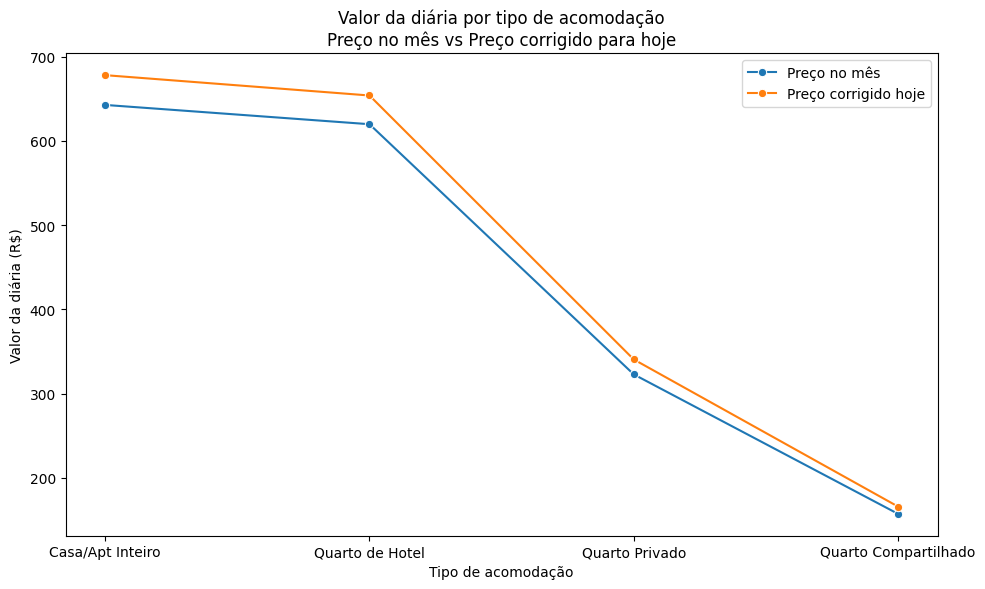

In [56]:

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df_plot,
    x="Tipo de acomodação",
    y="Valor da diária",
    hue="Momento",
    marker="o"
)

plt.title("Valor da diária por tipo de acomodação\nPreço no mês vs Preço corrigido para hoje")
plt.xlabel("Tipo de acomodação")
plt.ylabel("Valor da diária (R$)")
plt.legend(title="")
plt.tight_layout()
plt.show()


In [ ]:

top_bairros = (
    df_tratado_price_min
    .groupby("bairro")
    .size()
    .reset_index(name="total_anuncios")
    .sort_values("total_anuncios", ascending=False)
    .head(10)
)


In [ ]:

df_preco_bairro = (
    df_tratado_price_min
    .groupby("bairro")["preco"]
    .mean()
    .reset_index()
)


In [ ]:

df_preco_bairro = df_preco_bairro.merge(
    top_bairros[["bairro"]],
    on="bairro",
    how="inner"
)


In [ ]:
ipca_atual = 5.5


df_preco_bairro["Preço corrigido hoje"] = (
    df_preco_bairro["preco"] *
    (1 + ipca_atual / 100)
)

df_preco_bairro = df_preco_bairro.rename(
    columns={"preco": "Preço no mês"}
)


In [ ]:

df_plot = df_preco_bairro.melt(
    id_vars="bairro",
    value_vars=["Preço no mês", "Preço corrigido hoje"],
    var_name="Momento",
    value_name="Valor da diária"
)


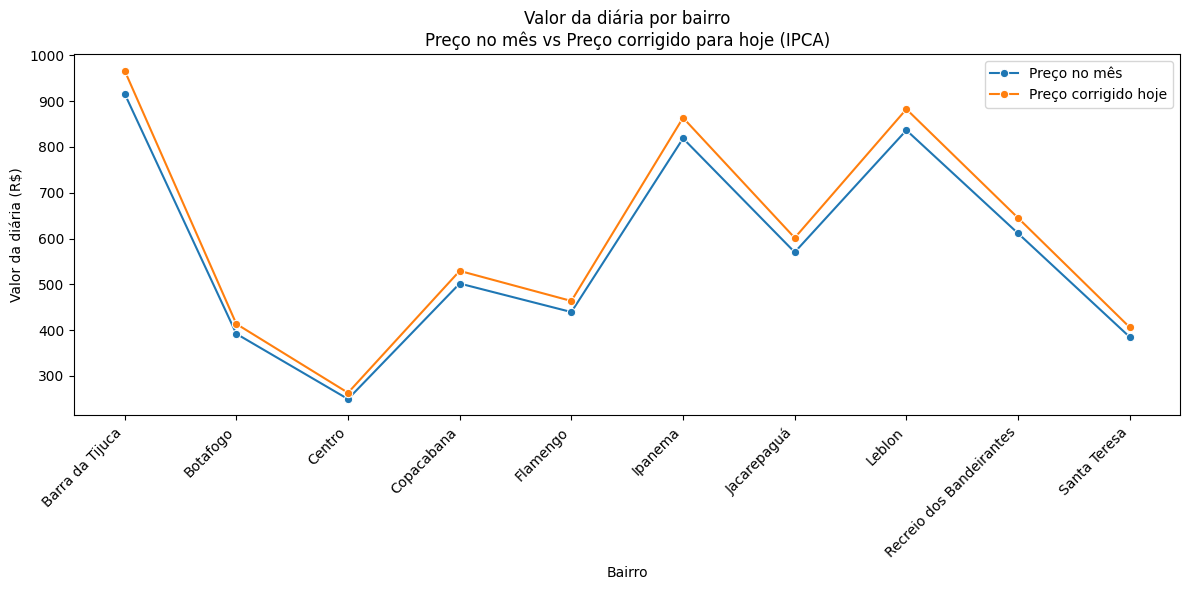

In [ ]:

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_plot,
    x="bairro",
    y="Valor da diária",
    hue="Momento",
    marker="o"
)

plt.title("Valor da diária por bairro\nPreço no mês vs Preço corrigido para hoje (IPCA)")
plt.xlabel("Bairro")
plt.ylabel("Valor da diária (R$)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="")
plt.tight_layout()
plt.show()
